- University : University of Milano-Bicocca
- Program : MS Data Science 2025-27
- Course : Data Management
- **Final Project**
- **Submitted by** :
  - **Fayyaz Hussain Shah - 946912**

### 1. Load Libraries

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### 2. Data Aquisition

#### 1. Source 1 : Kaggle Dataset - https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2021

In [2]:
df = pd.read_csv('world-happiness-report.csv')

##### Transformation/Enrichment & CLeaning

Null Values

In [3]:
df.isnull().sum()
df['Log GDP per capita'] = df['Log GDP per capita'].fillna(df['Log GDP per capita'].median()) # Data Quality Assesment Dimension 1

Formatting

In [4]:
df = df.drop_duplicates()

In [5]:
df['Country name'] = df['Country name'].str.strip()

df['Country name'] = df['Country name'].str.title()

df["year"] = df["year"].astype(int)

Fix Missing Year's Data

In [6]:
def fill_missing_years(df):
    # Find the range of years
    df['year'] = df['year'].astype(int)

    # Get full range of years in dataset
    year_min = df['year'].min()
    year_max = df['year'].max()

    # Get list of countries
    countries = df['Country name'].unique()

    # Create full grid
    full_grid = pd.MultiIndex.from_product(
        [countries, range(year_min, year_max + 1)],
        names=['Country name', 'year']
    ).to_frame(index=False)

    # Left merge ensures all countries x years exist
    df_full = full_grid.merge(df, on=['Country name', 'year'], how='left')

    # Sort by country and year
    df_full = df_full.sort_values(['Country name', 'year'])

    # Numeric columns to fill
    numeric_cols = ['Life Ladder', 'Log GDP per capita', 'Social support',
                    'Healthy life expectancy at birth', 'Freedom to make life choices',
                    'Generosity', 'Perceptions of corruption']

    # Interpolate missing values
    df_full[numeric_cols] = df_full.groupby('Country name')[numeric_cols].transform(lambda g: g.interpolate())

    # Forward/backward fill if first/last years were missing
    df_full[numeric_cols] = df_full.groupby('Country name')[numeric_cols].transform(lambda g: g.ffill().bfill())
    return df_full

In [7]:
df=fill_missing_years(df)

In [8]:
df = df[['Country name', 'year', 'Life Ladder', 'Log GDP per capita']]

#### 2. Source 2 : API

In [9]:
# Years 2020-2025
start_year = 2020
end_year = 2025

# API URL for GDP per capita for all countries
api_url = (f"http://api.worldbank.org/v2/country/all/indicator/NY.GDP"
           f".PCAP.CD?date={start_year}:{end_year}&format=json&per_page=20000")

response = requests.get(api_url)
data = response.json()

# Extract relevant data
records = []
for entry in data[1]:  # data[0] has metadata
    country = entry['country']['value']
    year = int(entry['date'])
    gdp_per_capita = entry['value']  # Can be None
    records.append({
        'Country name': country,
        'year': year,
        'GDP per capita': gdp_per_capita
    })

df_api = pd.DataFrame(records)

##### Transformation/Enrichment & CLeaning

Null Values

In [10]:
# Drop missing GDP values
df_api = df_api.dropna(subset=['GDP per capita'])

Fomratting

In [11]:
# Calculate Log GDP per capita
df_api['Log GDP per capita'] = np.log(df_api['GDP per capita'])

# Drop original GDP per capita if not needed
df_api = df_api[['Country name', 'year', 'Log GDP per capita']]

In [12]:
df_api.head()

,Country name,year,Log GDP per capita
0,Africa Eastern and Southern,2024,7.357324
1,Africa Eastern and Southern,2023,7.320357
2,Africa Eastern and Southern,2022,7.395303
3,Africa Eastern and Southern,2021,7.328039
4,Africa Eastern and Southern,2020,7.203482


### 2. Merge Data

In [13]:
# Integration
df_merged = pd.concat([df, df_api], ignore_index=True)

# Sorting
df_merged = df_merged.sort_values(['Country name', 'year']).reset_index(drop=True)

In [14]:
df_merged.head(20)

,Country name,year,Life Ladder,Log GDP per capita
0,Afghanistan,2005,3.724,7.370000
1,Afghanistan,2006,3.724,7.370000
2,Afghanistan,2007,3.724,7.370000
3,Afghanistan,2008,3.724,7.370000
4,Afghanistan,2009,4.402,7.540000
5,Afghanistan,2010,4.758,7.647000
6,Afghanistan,2011,3.832,7.620000
7,Afghanistan,2012,3.783,7.705000
8,Afghanistan,2013,3.572,7.725000
9,Afghanistan,2014,3.131,7.718000


### 3. Handle Missing Data

In [15]:
df_merged.isnull().sum()
df_merged['Life Ladder'] = df_merged.groupby('Country name')['Life Ladder'].transform(lambda x: x.interpolate())
df_merged['Life Ladder'] = df_merged['Life Ladder'].fillna(df['Life Ladder'].median())

In [16]:
df_merged.head(20)

,Country name,year,Life Ladder,Log GDP per capita
0,Afghanistan,2005,3.724,7.370000
1,Afghanistan,2006,3.724,7.370000
2,Afghanistan,2007,3.724,7.370000
3,Afghanistan,2008,3.724,7.370000
4,Afghanistan,2009,4.402,7.540000
5,Afghanistan,2010,4.758,7.647000
6,Afghanistan,2011,3.832,7.620000
7,Afghanistan,2012,3.783,7.705000
8,Afghanistan,2013,3.572,7.725000
9,Afghanistan,2014,3.131,7.718000


### 4. EDA

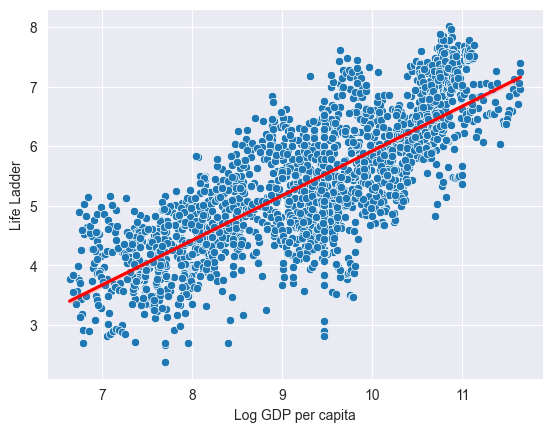

In [26]:
sns.scatterplot(x='Log GDP per capita', y='Life Ladder', data=df)
sns.regplot(x='Log GDP per capita', y='Life Ladder', data=df, scatter=False, color='red')
plt.show()

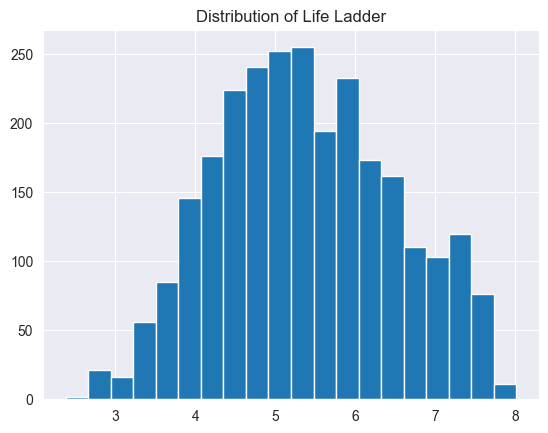

In [18]:
df["Life Ladder"].hist(bins=20)
plt.title("Distribution of Life Ladder")
plt.show()

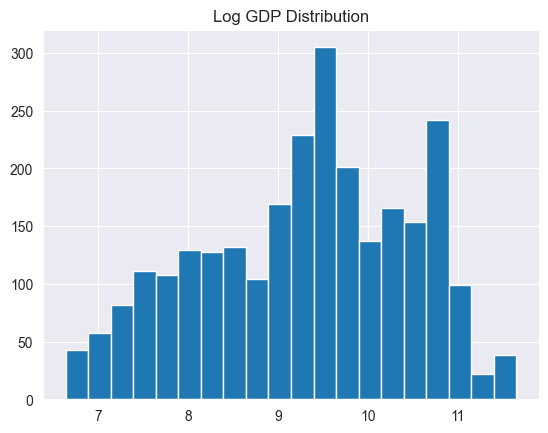

In [19]:
df["Log GDP per capita"].hist(bins=20)
plt.title("Log GDP Distribution")
plt.show()

In [20]:
df.groupby("Country name")["Life Ladder"].mean().sort_values(ascending=False).head(10)

Country name
Denmark        7.695781
Finland        7.602406
Switzerland    7.555594
Norway         7.536875
Netherlands    7.472031
Canada         7.380937
Sweden         7.365656
Iceland        7.309906
New Zealand    7.309469
Australia      7.288375
Name: Life Ladder, dtype: float64

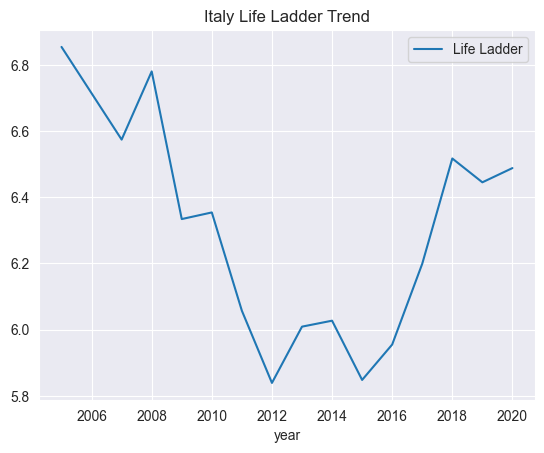

In [21]:
country = "Italy"
df[df["Country name"] == country].plot(x="year", y="Life Ladder", title=f"{country} Life Ladder Trend")
plt.show()

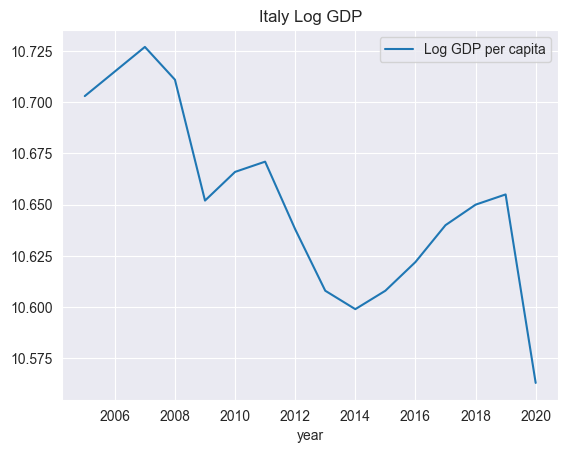

In [27]:
country = "Italy"
df[df["Country name"] == country].plot(x="year", y="Log GDP per capita", title=f"{country} Log GDP")
plt.show()

In [23]:
df_merged.isna().mean()*100

Country name          0.0
year                  0.0
Life Ladder           0.0
Log GDP per capita    0.0
dtype: float64

### 5. Save Data - SQL

In [24]:
conn = sqlite3.connect("WHR.db")
df_merged.to_sql("World_Happiness_Report", conn, if_exists="replace", index=False)
conn.close()